АНАЛИЗ НЕЙРОСЕТЕВОЙ ПУНКТУАЦИОННОЙ РАЗМЕТКИ
Золотой стандарт: 11402 токенов, 2392 знаков

Анализ модели: DeepSeek
  Точность обнаружения: 87.4%
  Type weighted F1: 0.8968
  Soft accuracy: 0.6003

Анализ модели: Qwen
  Точность обнаружения: 90.2%
  Type weighted F1: 0.8814
  Soft accuracy: 0.4900

Анализ модели: Alice.AI
  Точность обнаружения: 22.7%
  Type weighted F1: 0.2748
  Soft accuracy: 0.1555
ИТОГОВЫЙ ОТЧЕТ
МОДЕЛЬ: DeepSeek

1. ОБНАРУЖЕНИЕ ЗНАКОВ:
   - Всего знаков: 2392
   - Верно найдено: 2090 (87.4%)
   - Пропущено: 302 (12.6%)
   - Лишних: 47

2. МЕТРИКИ ТОЧНОСТИ:
   - Exact Match: 0.5606
   - Type Accuracy: 0.8683
   - Soft Accuracy: 0.6003

3. ВЗВЕШЕННЫЕ F1:
   - По типам знаков: 0.8968
   - По пробелам: 0.8689
   - По статусу: 0.9320
   - По нормативности: 0.7286

4. ФУНКЦИИ:
   - Soft accuracy: 0.6003
МОДЕЛЬ: Qwen

1. ОБНАРУЖЕНИЕ ЗНАКОВ:
   - Всего знаков: 2392
   - Верно найдено: 2158 (90.2%)
   - Пропущено: 234 (9.8%)
   - Лишних: 281

2. МЕТРИКИ ТОЧНОСТИ:
   - Exact M

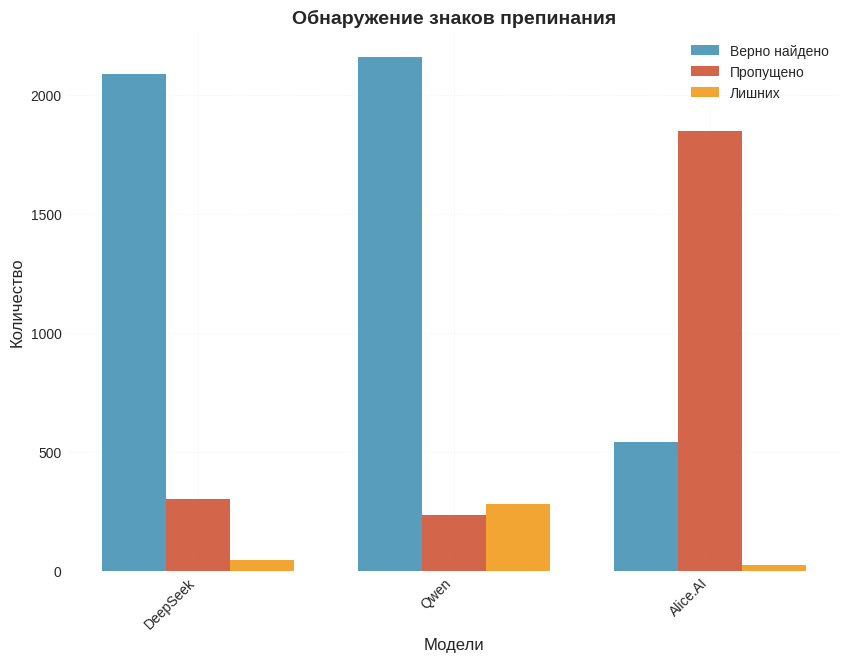

  - Показан и сохранен: plots/1_detection_chart.png


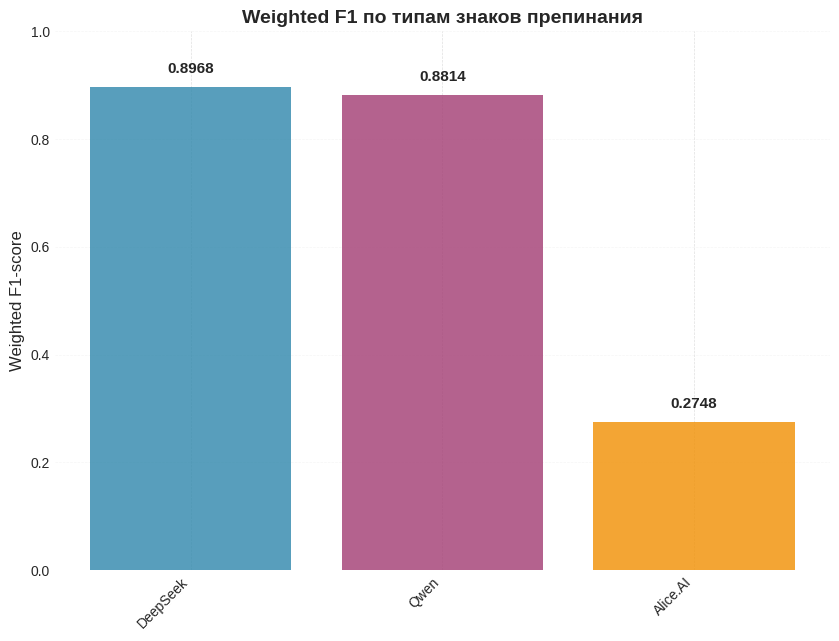

  - Сохранен: plots/2_type_f1_comparison.png


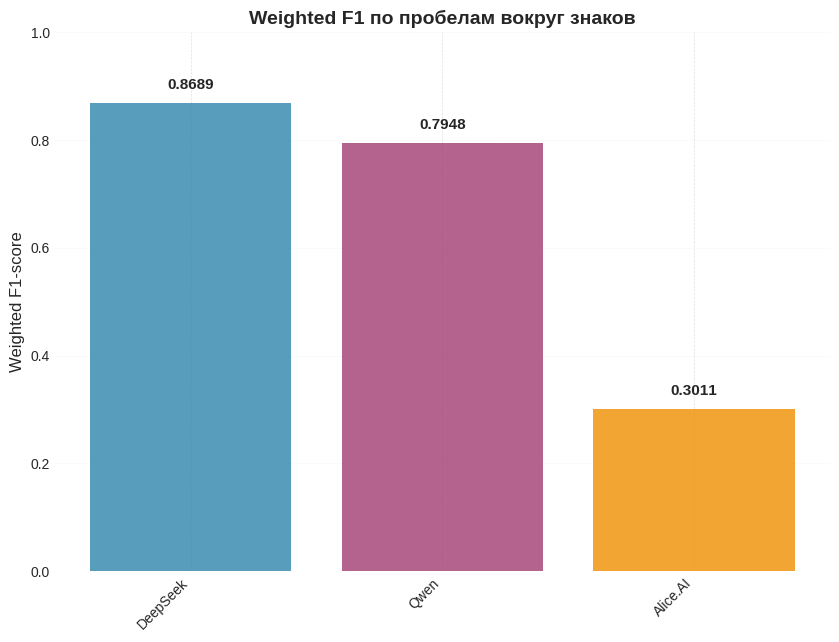

  - Сохранен: plots/3_space_f1_comparison.png


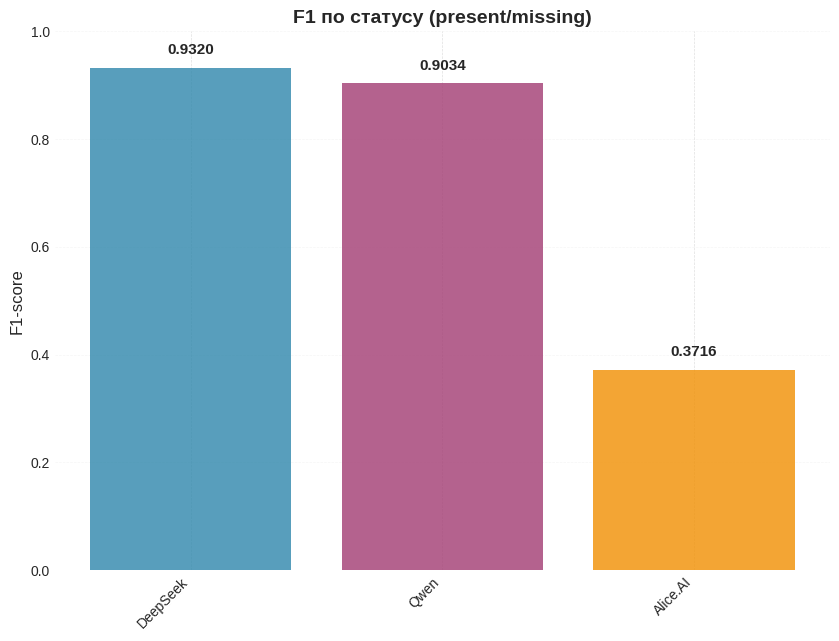

  - Сохранен: plots/4_status_f1_comparison.png


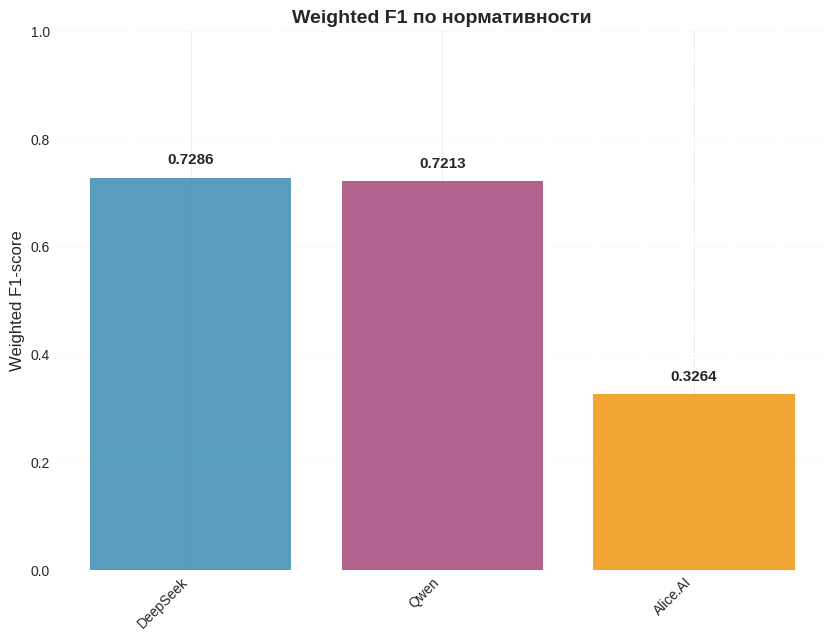

  - Сохранен: plots/5_normality_f1_comparison.png


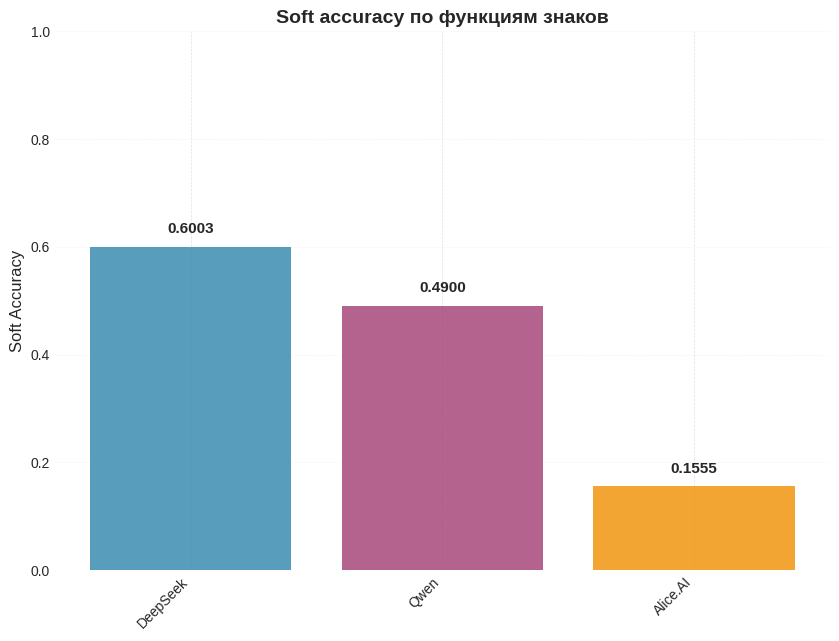

  - Сохранен: plots/6_soft_accuracy_comparison.png


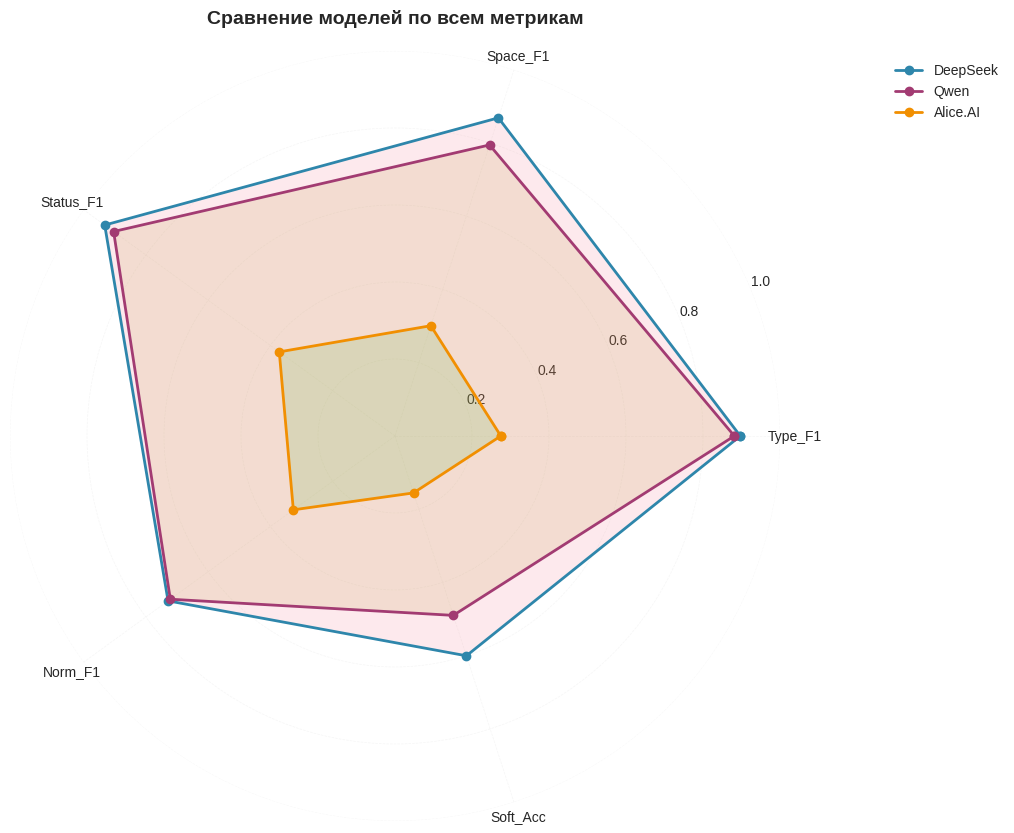

  - Сохранен: plots/7_radar_chart.png


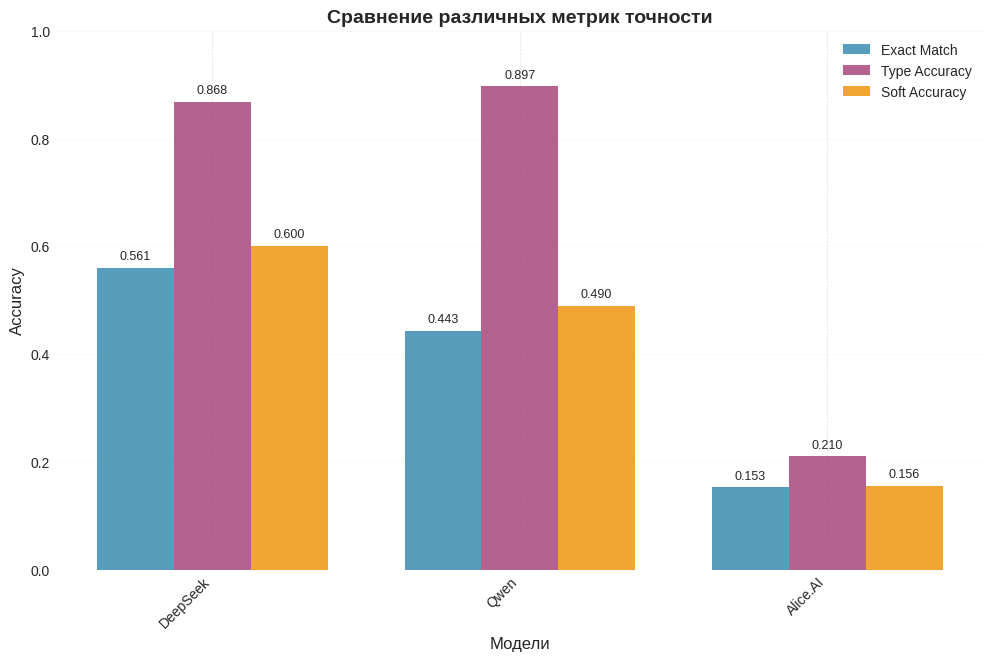

  - Сохранен: plots/8_accuracy_metrics_comparison.png


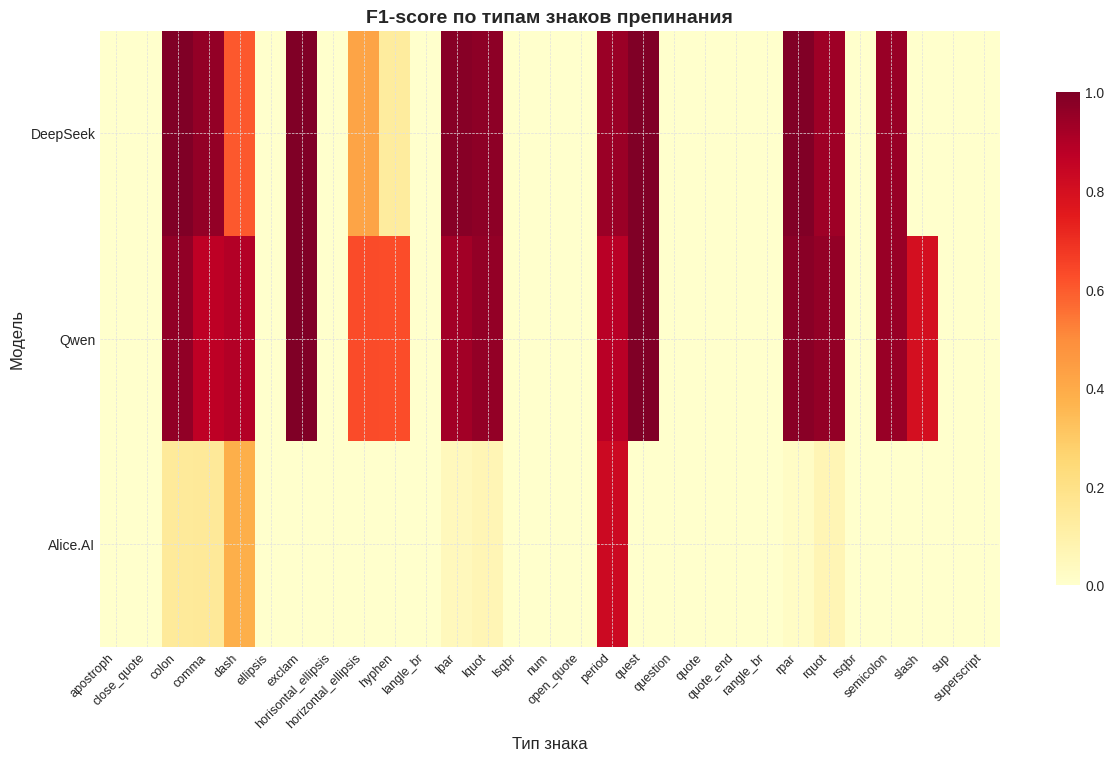

  - Сохранен: plots/9_heatmap_by_type.png


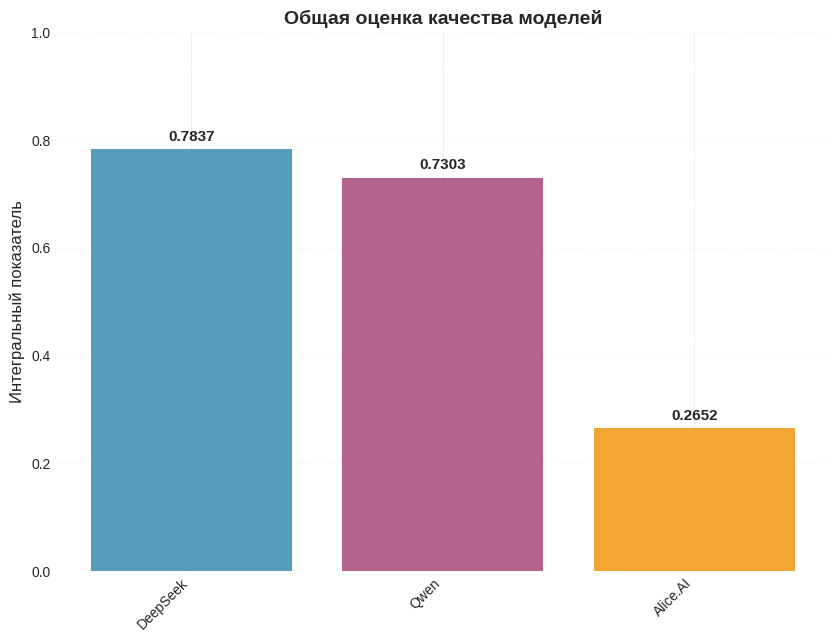

  - Сохранен: plots/10_overall_scores.png


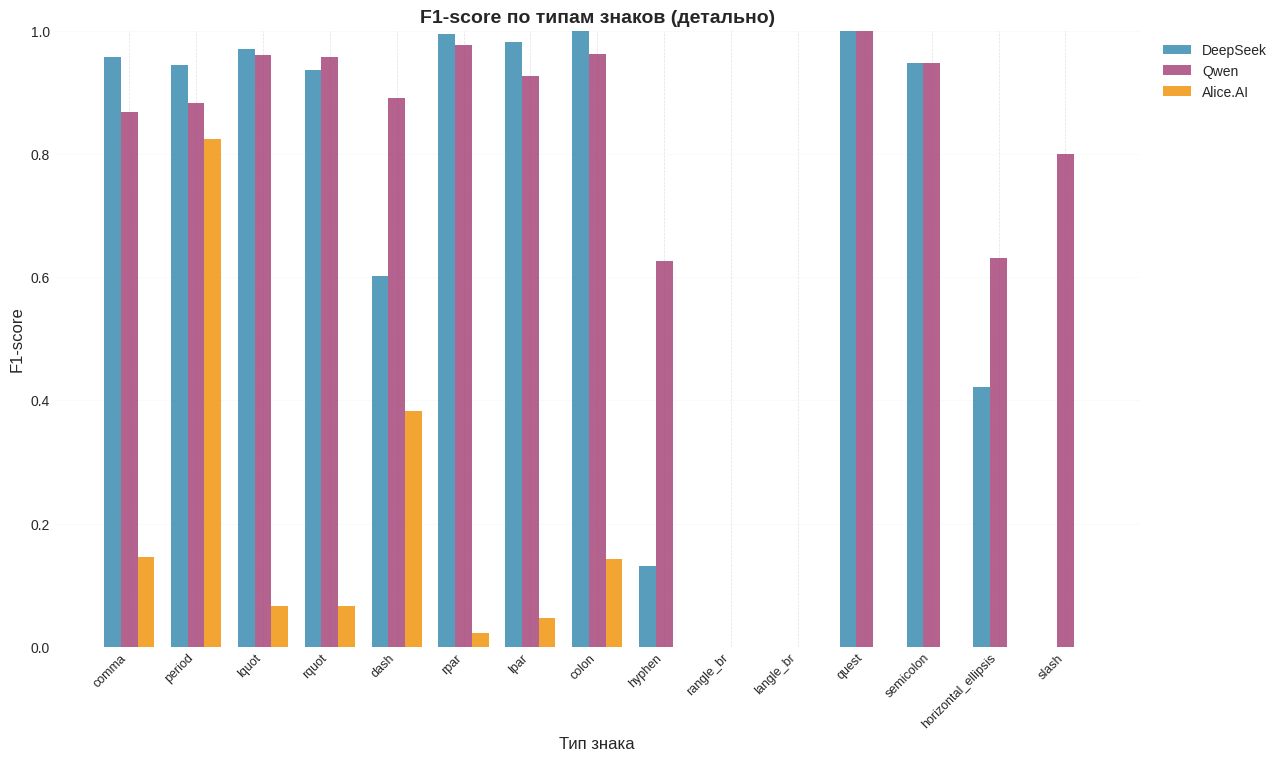

  - Сохранен: plots/11_per_type_f1_bars.png


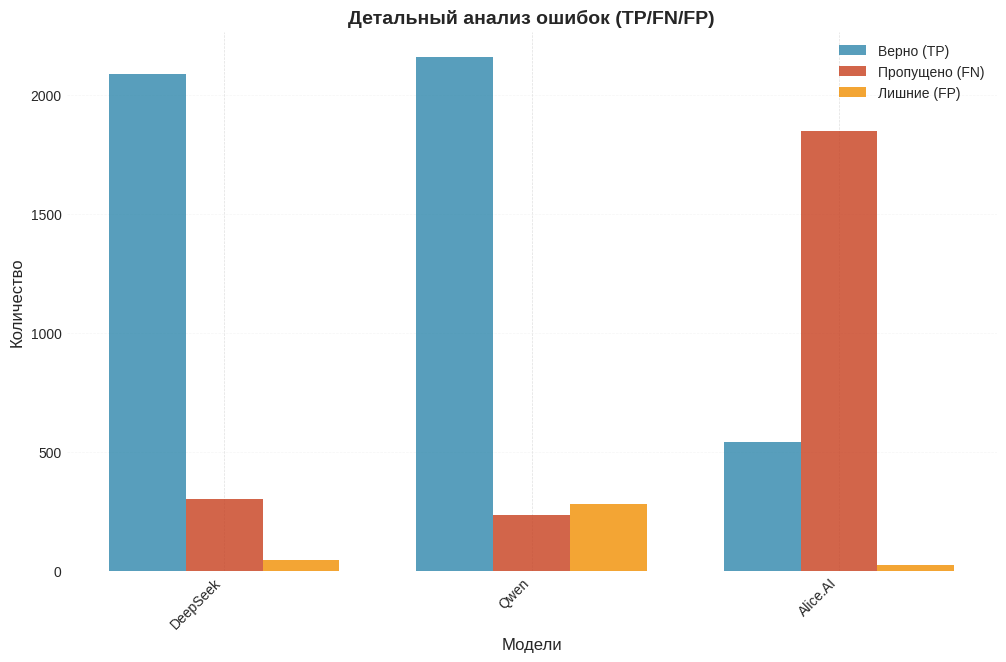

  - Показан и сохранен: plots/12_error_analysis.png

Все графики сохранены в папку 'plots/'

Анализ завершен!


In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from difflib import SequenceMatcher
import warnings
import os
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['grid.color'] = '#e0e0e0'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True

os.makedirs('plots', exist_ok=True)

class PunctuationAnalyzer:
    def __init__(self):
        self.function_inventory = self._build_function_inventory()

        self.valid_punct_types = {
            'period', 'comma', 'quest', 'exclam', 'colon', 'semicolon',
            'lquot', 'rquot', 'lpar', 'rpar', 'lsqbr', 'rsqbr',
            'langle_br', 'rangle_br', 'dash', 'hyphen', 'slash', 'apostroph'
        }

        self.valid_space_values = {'zero', 'left', 'right', 'bilateral', 'none'}
        self.valid_status_values = {'present', 'missing'}
        self.valid_normality_values = {'correct', 'mistake', 'alt', 'facult', 'var', 'ind', 'typo'}

    def _build_function_inventory(self):
        functions = {
            'end_sent', 'ellipsis', 'abbrev_name', 'abbrev_word', 'date', 'biblio',
            'number', 'title', 'link', 'censorship', 'parc', 'comma', 'long_pause',
            'thinking', 'severe', 'humor', 'extra', 'equal', 'vocative', 'expletive',
            'specifier', 'participle', 'adv_participle', 'no', 'yes', 'interjection',
            'object', 'similie', 'identity', 'adverbial', 'attribute', 'apposition',
            'fronting', 'direct_end', 'direct_break', 'dialog_end', 'dialog_break',
            'reported_start', 'inclus', 'exclus', 'remark', 'subj_pred', 'explanation',
            'short_pause', 'exclam', 'emotion', 'loud', 'sincere', 'question',
            'general_equal', 'general_const', 'dialog_start', 'dialog_inner',
            'direct_start', 'indirect_speech', 'average_pause', 'join', 'open_par',
            'close_par', 'list', 'reduction_start', 'reduction_finish', 'name_begin',
            'name_finish', 'quote_begin', 'quote_finish', 'digit_name_begin',
            'digit_name_finish', 'letter_name_begin', 'letter_name_finish',
            'expr_begin', 'expr_finish', 'term_begin', 'term_finish', 'out_quotes',
            'inner_quotes', 'figur', 'irony', 'detachment', 'range', 'blank', 'order',
            'opposition', 'connect', 'route', 'sequence', 'hier', 'pathos', 'accent',
            'message_end', 'word_parts', 'hyphen', 'phrase2word', 'options', 'group',
            'neo', 'long_sound', 'slash', 'poem2line', 'equal_clauses', 'compos',
            'united_clauses', 'divided_clauses', 'oppos_clauses', 'follow', 'explan',
            'subord', 'seq_clauses', 'parallel_clauses', 'determ_clause', 'explan_clause',
            'circum_clause', 'time_clause', 'loc_clause', 'reason_clause', 'aim_clause',
            'cond_clause', 'conces_clause', 'compar_clause', 'match_clause', 'mode_clause',
            'degree_clause', 'no_union', 'same_time', 'conseq', 'oppos', 'compar', 'cond', 'enum'
        }
        return functions

    def parse_xml_with_tokens(self, filepath):
        try:
            tree = ET.parse(filepath)
            root = tree.getroot()
        except:
            try:
                with open(filepath, 'r', encoding='utf-8') as f:
                    content = f.read()
                root = ET.fromstring(content)
            except:
                with open(filepath, 'r', encoding='utf-8-sig') as f:
                    content = f.read()
                root = ET.fromstring(content)

        tokens = []

        for elem in root.iter():
            if elem.tag == 'w':
                text = ''.join(elem.itertext()).strip()
                if text:
                    tokens.append({'type': 'word', 'text': text, 'position': len(tokens)})
            elif elem.tag == 'pc':
                text = elem.text if elem.text else ''
                punct_type = elem.get('type', 'unknown')
                is_valid_type = punct_type in self.valid_punct_types
                pc_data = {
                    'type': 'punct',
                    'text': text,
                    'punct_type': punct_type,
                    'is_valid_type': is_valid_type,
                    'status': elem.get('status', 'present'),
                    'functions': elem.get('functions', ''),
                    'normality': elem.get('normality', 'correct'),
                    'spaces': elem.get('spaces', 'none'),
                    'expression': elem.get('expression', ''),
                    'reliance': elem.get('reliance', None),
                    'position': len(tokens)
                }
                if pc_data['functions']:
                    pc_data['functions_list'] = [f.strip() for f in pc_data['functions'].split(',') if f.strip()]
                    pc_data['valid_functions'] = [f for f in pc_data['functions_list'] if f in self.function_inventory]
                    pc_data['invalid_functions'] = [f for f in pc_data['functions_list'] if f not in self.function_inventory]
                else:
                    pc_data['functions_list'] = []
                    pc_data['valid_functions'] = []
                    pc_data['invalid_functions'] = []
                tokens.append(pc_data)
            elif elem.tag == 'span':
                for pc in elem.findall('.//pc'):
                    if pc.get('status') == 'missing':
                        punct_type = pc.get('type', 'unknown')
                        is_valid_type = punct_type in self.valid_punct_types
                        pc_data = {
                            'type': 'punct',
                            'text': '',
                            'punct_type': punct_type,
                            'is_valid_type': is_valid_type,
                            'status': 'missing',
                            'functions': pc.get('functions', ''),
                            'normality': pc.get('normality', 'mistake'),
                            'spaces': pc.get('spaces', 'none'),
                            'expression': pc.get('expression', ''),
                            'reliance': pc.get('reliance', None),
                            'position': len(tokens)
                        }
                        if pc_data['functions']:
                            pc_data['functions_list'] = [f.strip() for f in pc_data['functions'].split(',') if f.strip()]
                            pc_data['valid_functions'] = [f for f in pc_data['functions_list'] if f in self.function_inventory]
                            pc_data['invalid_functions'] = [f for f in pc_data['functions_list'] if f not in self.function_inventory]
                        else:
                            pc_data['functions_list'] = []
                            pc_data['valid_functions'] = []
                            pc_data['invalid_functions'] = []
                        tokens.append(pc_data)

        punctuation = [t for t in tokens if t['type'] == 'punct']
        return tokens, punctuation

    def align_sequences(self, gold_tokens, pred_tokens):
        gold_seq = [f"W:{t['text']}" if t['type'] == 'word' else f"P:{t['punct_type']}" for t in gold_tokens]
        pred_seq = [f"W:{t['text']}" if t['type'] == 'word' else f"P:{t['punct_type']}" for t in pred_tokens]

        matcher = SequenceMatcher(None, gold_seq, pred_seq)
        aligned_gold = []
        aligned_pred = []

        for tag, i1, i2, j1, j2 in matcher.get_opcodes():
            if tag == 'equal':
                for k in range(i2 - i1):
                    aligned_gold.append(gold_tokens[i1 + k])
                    aligned_pred.append(pred_tokens[j1 + k])
            elif tag == 'replace':
                for k in range(max(i2 - i1, j2 - j1)):
                    if k < (i2 - i1):
                        aligned_gold.append(gold_tokens[i1 + k])
                    else:
                        aligned_gold.append({'type': 'placeholder', 'is_placeholder': True})
                    if k < (j2 - j1):
                        aligned_pred.append(pred_tokens[j1 + k])
                    else:
                        aligned_pred.append({'type': 'placeholder', 'is_placeholder': True})
            elif tag == 'delete':
                for k in range(i2 - i1):
                    aligned_gold.append(gold_tokens[i1 + k])
                    aligned_pred.append({'type': 'placeholder', 'is_placeholder': True})
            elif tag == 'insert':
                for k in range(j2 - j1):
                    aligned_gold.append({'type': 'placeholder', 'is_placeholder': True})
                    aligned_pred.append(pred_tokens[j1 + k])

        return aligned_gold, aligned_pred

    def extract_punctuation_from_aligned(self, aligned_gold, aligned_pred):
        gold_punct = []
        pred_punct = []

        for g, p in zip(aligned_gold, aligned_pred):
            g_is_punct = (g.get('type') == 'punct')
            p_is_punct = (p.get('type') == 'punct')

            if g_is_punct or p_is_punct:
                if g_is_punct:
                    gold_item = {
                        'index': len(gold_punct),
                        'type': g.get('punct_type', 'unknown'),
                        'is_valid_type': g.get('is_valid_type', False),
                        'status': g.get('status', 'present'),
                        'functions_list': g.get('functions_list', []),
                        'spaces': g.get('spaces', 'none'),
                        'normality': g.get('normality', 'correct'),
                        'text': g.get('text', '')
                    }
                else:
                    gold_item = None

                if p_is_punct:
                    pred_item = {
                        'index': len(pred_punct),
                        'type': p.get('punct_type', 'unknown'),
                        'is_valid_type': p.get('is_valid_type', False),
                        'status': p.get('status', 'present'),
                        'functions_list': p.get('functions_list', []),
                        'spaces': p.get('spaces', 'none'),
                        'normality': p.get('normality', 'correct'),
                        'text': p.get('text', '')
                    }
                else:
                    pred_item = None

                gold_punct.append(gold_item)
                pred_punct.append(pred_item)

        return gold_punct, pred_punct

    def compare_punctuation_aligned(self, gold_punct, pred_punct):
        results = {
            'true_positive': 0, 'false_positive': 0, 'false_negative': 0,
            'exact_matches': 0, 'type_matches': 0, 'space_matches': 0,
            'status_matches': 0, 'normality_matches': 0,
            'accuracy_metrics': {}
        }

        type_correct = 0
        soft_correct = 0
        exact_correct = 0

        for gold_item, pred_item in zip(gold_punct, pred_punct):
            if gold_item is not None and pred_item is not None:
                results['true_positive'] += 1

                if (gold_item['type'] == pred_item['type'] and
                    gold_item['spaces'] == pred_item['spaces'] and
                    gold_item['status'] == pred_item['status'] and
                    self.compare_functions(gold_item['functions_list'], pred_item['functions_list'])):
                    results['exact_matches'] += 1
                    exact_correct += 1

                if gold_item['type'] == pred_item['type']:
                    results['type_matches'] += 1
                    type_correct += 1

                if gold_item['spaces'] == pred_item['spaces']:
                    results['space_matches'] += 1

                if gold_item['status'] == pred_item['status']:
                    results['status_matches'] += 1

                if gold_item.get('normality') == pred_item.get('normality'):
                    results['normality_matches'] += 1

                if self.compare_functions(gold_item['functions_list'], pred_item['functions_list']):
                    soft_correct += 1

            elif gold_item is not None and pred_item is None:
                results['false_negative'] += 1
            elif gold_item is None and pred_item is not None:
                results['false_positive'] += 1

        total_comparisons = len([g for g in gold_punct if g is not None])
        if total_comparisons > 0:
            results['accuracy_metrics']['exact_match_accuracy'] = exact_correct / total_comparisons
            results['accuracy_metrics']['type_accuracy'] = type_correct / total_comparisons
            results['accuracy_metrics']['soft_accuracy'] = soft_correct / total_comparisons

        return results

    def compare_functions(self, gold_functions, pred_functions):
        if not gold_functions and not pred_functions:
            return True
        if not gold_functions or not pred_functions:
            return False
        return len(set(gold_functions) & set(pred_functions)) > 0

    def calculate_type_metrics(self, gold_punct, pred_punct):
        gold_types = [g['type'] if g is not None else 'NO_PUNCT' for g in gold_punct]
        pred_types = [p['type'] if p is not None else 'NO_PUNCT' for p in pred_punct]

        all_types = sorted(set([t for t in gold_types + pred_types if t != 'NO_PUNCT']))
        metrics = {}

        for p_type in all_types:
            y_true = [1 if t == p_type else 0 for t in gold_types]
            y_pred = [1 if t == p_type else 0 for t in pred_types]
            metrics[p_type] = {
                'precision': precision_score(y_true, y_pred, zero_division=0),
                'recall': recall_score(y_true, y_pred, zero_division=0),
                'f1': f1_score(y_true, y_pred, zero_division=0),
                'count_gold': sum(y_true)
            }

        total_gold = len([t for t in gold_types if t != 'NO_PUNCT'])
        if total_gold > 0:
            weighted_f1 = sum(m['f1'] * m['count_gold'] for m in metrics.values()) / total_gold
        else:
            weighted_f1 = 0

        return {'per_type': metrics, 'weighted_f1': weighted_f1}

    def calculate_space_metrics(self, gold_punct, pred_punct):
        gold_spaces = [g['spaces'] if g is not None else 'NO_PUNCT' for g in gold_punct]
        pred_spaces = [p['spaces'] if p is not None else 'NO_PUNCT' for p in pred_punct]

        space_types = ['zero', 'left', 'right', 'bilateral', 'none']
        metrics = {}

        for space_type in space_types:
            y_true = [1 if s == space_type else 0 for s in gold_spaces]
            y_pred = [1 if s == space_type else 0 for s in pred_spaces]
            metrics[space_type] = {
                'f1': f1_score(y_true, y_pred, zero_division=0),
                'count_gold': sum(y_true)
            }

        total_gold = len([s for s in gold_spaces if s != 'NO_PUNCT'])
        weighted_f1 = sum(m['f1'] * m['count_gold'] for m in metrics.values()) / total_gold if total_gold > 0 else 0
        return {'per_type': metrics, 'weighted_f1': weighted_f1}

    def calculate_status_metrics(self, gold_punct, pred_punct):
        gold_status = [1 if g and g['status'] == 'present' else 0 for g in gold_punct]
        pred_status = [1 if p and p['status'] == 'present' else 0 for p in pred_punct]
        return {'f1': f1_score(gold_status, pred_status, zero_division=0)}

    def calculate_normality_metrics(self, gold_punct, pred_punct):
        gold_norm = [g.get('normality', 'correct') if g else 'NO_PUNCT' for g in gold_punct]
        pred_norm = [p.get('normality', 'correct') if p else 'NO_PUNCT' for p in pred_punct]

        norm_types = ['correct', 'mistake', 'alt', 'facult', 'var', 'ind', 'typo']
        metrics = {}

        for norm_type in norm_types:
            y_true = [1 if n == norm_type else 0 for n in gold_norm]
            y_pred = [1 if n == norm_type else 0 for n in pred_norm]
            metrics[norm_type] = {
                'f1': f1_score(y_true, y_pred, zero_division=0),
                'count_gold': sum(y_true)
            }

        total_gold = len([n for n in gold_norm if n != 'NO_PUNCT'])
        weighted_f1 = sum(m['f1'] * m['count_gold'] for m in metrics.values()) / total_gold if total_gold > 0 else 0
        return {'weighted_f1': weighted_f1}

    def calculate_function_metrics(self, gold_punct, pred_punct):
        soft_matches = 0
        total = 0

        for g, p in zip(gold_punct, pred_punct):
            if g is None:
                continue
            total += 1
            gold_set = set(g['functions_list'])
            pred_set = set(p['functions_list']) if p else set()
            if gold_set & pred_set:
                soft_matches += 1

        return {'soft_accuracy': soft_matches / total if total > 0 else 0}

def analyze_models(gold_file, model_files):
    analyzer = PunctuationAnalyzer()

    gold_tokens, gold_punct = analyzer.parse_xml_with_tokens(gold_file)
    print(f"Золотой стандарт: {len(gold_tokens)} токенов, {len(gold_punct)} знаков")

    results = {}

    for model_name, model_file in model_files.items():
        print(f"\nАнализ модели: {model_name}")
        try:
            pred_tokens, _ = analyzer.parse_xml_with_tokens(model_file)
            aligned_gold, aligned_pred = analyzer.align_sequences(gold_tokens, pred_tokens)
            gold_punct_aligned, pred_punct_aligned = analyzer.extract_punctuation_from_aligned(aligned_gold, aligned_pred)
            comparison = analyzer.compare_punctuation_aligned(gold_punct_aligned, pred_punct_aligned)

            results[model_name] = {
                'detection': comparison,
                'type_metrics': analyzer.calculate_type_metrics(gold_punct_aligned, pred_punct_aligned),
                'space_metrics': analyzer.calculate_space_metrics(gold_punct_aligned, pred_punct_aligned),
                'status_metrics': analyzer.calculate_status_metrics(gold_punct_aligned, pred_punct_aligned),
                'normality_metrics': analyzer.calculate_normality_metrics(gold_punct_aligned, pred_punct_aligned),
                'function_metrics': analyzer.calculate_function_metrics(gold_punct_aligned, pred_punct_aligned)
            }

            total = comparison['true_positive'] + comparison['false_negative']
            print(f"  Точность обнаружения: {comparison['true_positive']/total*100:.1f}%")
            print(f"  Type weighted F1: {results[model_name]['type_metrics']['weighted_f1']:.4f}")
            print(f"  Soft accuracy: {results[model_name]['function_metrics']['soft_accuracy']:.4f}")

        except Exception as e:
            print(f"  ОШИБКА: {e}")
            continue

    return results


def plot_and_save(fig, filename):
    fig.savefig(filename, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)


def plot_detection_chart(results):
    fig, ax = plt.subplots(figsize=(10, 7))
    models = list(results.keys())

    true_pos = [results[m]['detection']['true_positive'] for m in models]
    false_neg = [results[m]['detection']['false_negative'] for m in models]
    false_pos = [results[m]['detection']['false_positive'] for m in models]

    x = np.arange(len(models))
    width = 0.25

    ax.bar(x - width, true_pos, width, label='Верно найдено', color='#2E86AB', alpha=0.8)
    ax.bar(x, false_neg, width, label='Пропущено', color='#C73E1D', alpha=0.8)
    ax.bar(x + width, false_pos, width, label='Лишних', color='#F18F01', alpha=0.8)

    ax.set_xlabel('Модели', fontsize=12)
    ax.set_ylabel('Количество', fontsize=12)
    ax.set_title('Обнаружение знаков препинания', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    plot_and_save(fig, 'plots/1_detection_chart.png')
    print("  - Показан и сохранен: plots/1_detection_chart.png")


def plot_type_f1_comparison(results):
    fig, ax = plt.subplots(figsize=(10, 7))
    models = list(results.keys())
    f1_scores = [results[m]['type_metrics']['weighted_f1'] for m in models]

    colors = ['#2E86AB', '#A23B72', '#F18F01']
    bars = ax.bar(models, f1_scores, color=colors[:len(models)], alpha=0.8)

    ax.set_ylabel('Weighted F1-score', fontsize=12)
    ax.set_title('Weighted F1 по типам знаков препинания', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')

    for bar, score in zip(bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    plot_and_save(fig, 'plots/2_type_f1_comparison.png')
    print("  - Сохранен: plots/2_type_f1_comparison.png")


def plot_space_f1_comparison(results):
    fig, ax = plt.subplots(figsize=(10, 7))
    models = list(results.keys())
    f1_scores = [results[m]['space_metrics']['weighted_f1'] for m in models]

    colors = ['#2E86AB', '#A23B72', '#F18F01']
    bars = ax.bar(models, f1_scores, color=colors[:len(models)], alpha=0.8)

    ax.set_ylabel('Weighted F1-score', fontsize=12)
    ax.set_title('Weighted F1 по пробелам вокруг знаков', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')

    for bar, score in zip(bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    plot_and_save(fig, 'plots/3_space_f1_comparison.png')
    print("  - Сохранен: plots/3_space_f1_comparison.png")


def plot_status_f1_comparison(results):
    fig, ax = plt.subplots(figsize=(10, 7))
    models = list(results.keys())
    f1_scores = [results[m]['status_metrics']['f1'] for m in models]

    colors = ['#2E86AB', '#A23B72', '#F18F01']
    bars = ax.bar(models, f1_scores, color=colors[:len(models)], alpha=0.8)

    ax.set_ylabel('F1-score', fontsize=12)
    ax.set_title('F1 по статусу (present/missing)', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')

    for bar, score in zip(bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    plot_and_save(fig, 'plots/4_status_f1_comparison.png')
    print("  - Сохранен: plots/4_status_f1_comparison.png")


def plot_normality_f1_comparison(results):
    fig, ax = plt.subplots(figsize=(10, 7))
    models = list(results.keys())
    f1_scores = [results[m]['normality_metrics']['weighted_f1'] for m in models]

    colors = ['#2E86AB', '#A23B72', '#F18F01']
    bars = ax.bar(models, f1_scores, color=colors[:len(models)], alpha=0.8)

    ax.set_ylabel('Weighted F1-score', fontsize=12)
    ax.set_title('Weighted F1 по нормативности', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')

    for bar, score in zip(bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    plot_and_save(fig, 'plots/5_normality_f1_comparison.png')
    print("  - Сохранен: plots/5_normality_f1_comparison.png")


def plot_soft_accuracy_comparison(results):
    fig, ax = plt.subplots(figsize=(10, 7))
    models = list(results.keys())
    soft_scores = [results[m]['function_metrics']['soft_accuracy'] for m in models]

    colors = ['#2E86AB', '#A23B72', '#F18F01']
    bars = ax.bar(models, soft_scores, color=colors[:len(models)], alpha=0.8)

    ax.set_ylabel('Soft Accuracy', fontsize=12)
    ax.set_title('Soft accuracy по функциям знаков', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')

    for bar, score in zip(bars, soft_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    plot_and_save(fig, 'plots/6_soft_accuracy_comparison.png')
    print("  - Сохранен: plots/6_soft_accuracy_comparison.png")


def plot_radar_chart(results):
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
    models = list(results.keys())

    metrics = ['Type_F1', 'Space_F1', 'Status_F1', 'Norm_F1', 'Soft_Acc']
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    colors = ['#2E86AB', '#A23B72', '#F18F01']

    for i, model in enumerate(models):
        values = [
            results[model]['type_metrics']['weighted_f1'],
            results[model]['space_metrics']['weighted_f1'],
            results[model]['status_metrics']['f1'],
            results[model]['normality_metrics']['weighted_f1'],
            results[model]['function_metrics']['soft_accuracy']
        ]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i % len(colors)])
        ax.fill(angles, values, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, size=10)
    ax.set_ylim([0, 1])
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax.set_title('Сравнение моделей по всем метрикам', size=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3)

    plot_and_save(fig, 'plots/7_radar_chart.png')
    print("  - Сохранен: plots/7_radar_chart.png")


def plot_accuracy_metrics_comparison(results):
    fig, ax = plt.subplots(figsize=(12, 7))
    models = list(results.keys())

    metrics_data = {
        'Exact Match': [results[m]['detection']['accuracy_metrics']['exact_match_accuracy'] for m in models],
        'Type Accuracy': [results[m]['detection']['accuracy_metrics']['type_accuracy'] for m in models],
        'Soft Accuracy': [results[m]['detection']['accuracy_metrics']['soft_accuracy'] for m in models]
    }

    x = np.arange(len(models))
    width = 0.25
    colors = ['#2E86AB', '#A23B72', '#F18F01']

    for i, (metric, values) in enumerate(metrics_data.items()):
        bars = ax.bar(x + i*width, values, width, label=metric, color=colors[i], alpha=0.8)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    ax.set_xlabel('Модели', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Сравнение различных метрик точности', fontsize=14, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.set_ylim([0, 1])
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')

    plot_and_save(fig, 'plots/8_accuracy_metrics_comparison.png')
    print("  - Сохранен: plots/8_accuracy_metrics_comparison.png")


def plot_heatmap_by_type(results):
    models = list(results.keys())

    all_types = set()
    for model in models:
        all_types.update(results[model]['type_metrics']['per_type'].keys())
    all_types = sorted(all_types)

    f1_matrix = []
    for model in models:
        row = []
        for p_type in all_types:
            if p_type in results[model]['type_metrics']['per_type']:
                row.append(results[model]['type_metrics']['per_type'][p_type]['f1'])
            else:
                row.append(0)
        f1_matrix.append(row)

    fig, ax = plt.subplots(figsize=(max(14, len(all_types) * 0.5), 8))
    im = ax.imshow(f1_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

    ax.set_xticks(range(len(all_types)))
    ax.set_yticks(range(len(models)))
    ax.set_xticklabels(all_types, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(models, fontsize=10)
    ax.set_title('F1-score по типам знаков препинания', fontsize=14, fontweight='bold')
    ax.set_xlabel('Тип знака', fontsize=12)
    ax.set_ylabel('Модель', fontsize=12)

    plt.colorbar(im, ax=ax, shrink=0.8)

    plot_and_save(fig, 'plots/9_heatmap_by_type.png')
    print("  - Сохранен: plots/9_heatmap_by_type.png")


def plot_overall_scores(results):
    fig, ax = plt.subplots(figsize=(10, 7))
    models = list(results.keys())

    scores = []
    for model in models:
        score = (results[model]['type_metrics']['weighted_f1'] * 0.25 +
                results[model]['space_metrics']['weighted_f1'] * 0.15 +
                results[model]['status_metrics']['f1'] * 0.15 +
                results[model]['normality_metrics']['weighted_f1'] * 0.15 +
                results[model]['function_metrics']['soft_accuracy'] * 0.30)
        scores.append(score)

    colors = ['#2E86AB', '#A23B72', '#F18F01']
    bars = ax.bar(models, scores, color=colors[:len(models)], alpha=0.8)

    ax.set_ylabel('Интегральный показатель', fontsize=12)
    ax.set_title('Общая оценка качества моделей', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')

    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    plot_and_save(fig, 'plots/10_overall_scores.png')
    print("  - Сохранен: plots/10_overall_scores.png")


def plot_per_type_f1_bars(results):
    models = list(results.keys())

    all_types = set()
    for model in models:
        all_types.update(results[model]['type_metrics']['per_type'].keys())
    type_counts = {}
    for p_type in all_types:
        count = 0
        for model in models:
            count += results[model]['type_metrics']['per_type'].get(p_type, {}).get('count_gold', 0)
        type_counts[p_type] = count
    all_types = sorted([t for t in all_types if type_counts.get(t, 0) > 5], key=lambda x: type_counts.get(x, 0), reverse=True)[:15]

    fig, ax = plt.subplots(figsize=(14, 8))
    x = np.arange(len(all_types))
    width = 0.25
    colors = ['#2E86AB', '#A23B72', '#F18F01']

    for i, model in enumerate(models):
        f1_values = [results[model]['type_metrics']['per_type'].get(t, {}).get('f1', 0) for t in all_types]
        ax.bar(x + i*width, f1_values, width, label=model, color=colors[i], alpha=0.8)

    ax.set_xlabel('Тип знака', fontsize=12)
    ax.set_ylabel('F1-score', fontsize=12)
    ax.set_title('F1-score по типам знаков (детально)', fontsize=14, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(all_types, rotation=45, ha='right', fontsize=9)
    ax.set_ylim([0, 1])
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    plot_and_save(fig, 'plots/11_per_type_f1_bars.png')
    print("  - Сохранен: plots/11_per_type_f1_bars.png")


def plot_error_analysis(results):
    fig, ax = plt.subplots(figsize=(12, 7))
    models = list(results.keys())

    detection = [results[m]['detection'] for m in models]

    true_pos = [d['true_positive'] for d in detection]
    false_neg = [d['false_negative'] for d in detection]
    false_pos = [d['false_positive'] for d in detection]

    x = np.arange(len(models))
    width = 0.25

    ax.bar(x - width, true_pos, width, label='Верно (TP)', color='#2E86AB', alpha=0.8)
    ax.bar(x, false_neg, width, label='Пропущено (FN)', color='#C73E1D', alpha=0.8)
    ax.bar(x + width, false_pos, width, label='Лишние (FP)', color='#F18F01', alpha=0.8)

    ax.set_xlabel('Модели', fontsize=12)
    ax.set_ylabel('Количество', fontsize=12)
    ax.set_title('Детальный анализ ошибок (TP/FN/FP)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')

    plot_and_save(fig, 'plots/12_error_analysis.png')
    print("  - Показан и сохранен: plots/12_error_analysis.png")


def generate_all_plots(results):

    plot_detection_chart(results)
    plot_type_f1_comparison(results)
    plot_space_f1_comparison(results)
    plot_status_f1_comparison(results)
    plot_normality_f1_comparison(results)
    plot_soft_accuracy_comparison(results)
    plot_radar_chart(results)
    plot_accuracy_metrics_comparison(results)
    plot_heatmap_by_type(results)
    plot_overall_scores(results)
    plot_per_type_f1_bars(results)
    plot_error_analysis(results)

    print("\nВсе графики сохранены в папку 'plots/'")


def print_report(results):
    print("ИТОГОВЫЙ ОТЧЕТ")

    for model_name, model_results in results.items():

        print(f"МОДЕЛЬ: {model_name}")

        det = model_results['detection']
        total = det['true_positive'] + det['false_negative']
        print(f"\n1. ОБНАРУЖЕНИЕ ЗНАКОВ:")
        print(f"   - Всего знаков: {total}")
        print(f"   - Верно найдено: {det['true_positive']} ({det['true_positive']/total*100:.1f}%)")
        print(f"   - Пропущено: {det['false_negative']} ({det['false_negative']/total*100:.1f}%)")
        print(f"   - Лишних: {det['false_positive']}")

        print(f"\n2. МЕТРИКИ ТОЧНОСТИ:")
        print(f"   - Exact Match: {det['accuracy_metrics']['exact_match_accuracy']:.4f}")
        print(f"   - Type Accuracy: {det['accuracy_metrics']['type_accuracy']:.4f}")
        print(f"   - Soft Accuracy: {det['accuracy_metrics']['soft_accuracy']:.4f}")

        print(f"\n3. ВЗВЕШЕННЫЕ F1:")
        print(f"   - По типам знаков: {model_results['type_metrics']['weighted_f1']:.4f}")
        print(f"   - По пробелам: {model_results['space_metrics']['weighted_f1']:.4f}")
        print(f"   - По статусу: {model_results['status_metrics']['f1']:.4f}")
        print(f"   - По нормативности: {model_results['normality_metrics']['weighted_f1']:.4f}")

        print(f"\n4. ФУНКЦИИ:")
        print(f"   - Soft accuracy: {model_results['function_metrics']['soft_accuracy']:.4f}")

    # Сравнение моделей
    print("СРАВНЕНИЕ МОДЕЛЕЙ")
    print(f"\n{'Модель':<15} {'Type_F1':<12} {'Space_F1':<12} {'Status_F1':<12} {'Norm_F1':<12} {'Soft_Acc':<12}")
    for model_name, model_results in results.items():
        print(f"{model_name:<15} {model_results['type_metrics']['weighted_f1']:<12.4f} "
              f"{model_results['space_metrics']['weighted_f1']:<12.4f} "
              f"{model_results['status_metrics']['f1']:<12.4f} "
              f"{model_results['normality_metrics']['weighted_f1']:<12.4f} "
              f"{model_results['function_metrics']['soft_accuracy']:<12.4f}")


def main():
    gold_file = "Лотман золотые 10 тысяч.xml"

    model_files = {
        "DeepSeek": "Лотман Дипсик 2.xml",
        "Qwen": "Лотман Квен.xml",
        "Alice.AI": "Лотман Алиса_compact.xml"
    }

    print("АНАЛИЗ НЕЙРОСЕТЕВОЙ ПУНКТУАЦИОННОЙ РАЗМЕТКИ")


    results = analyze_models(gold_file, model_files)

    if not results:
        print("\nОшибка: не удалось проанализировать ни одну модель")
        return

    print_report(results)
    generate_all_plots(results)

    print("\nАнализ завершен!")


if __name__ == "__main__":
    main()

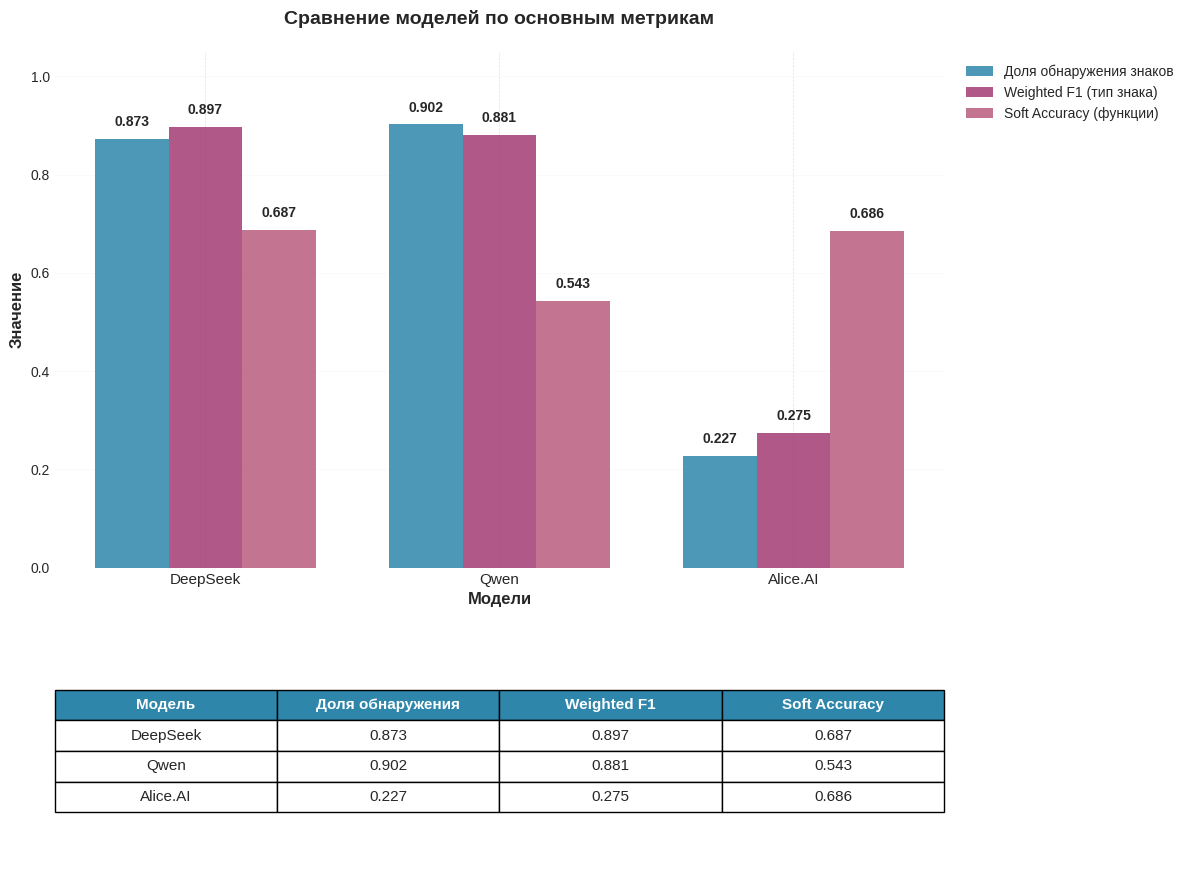


График с таблицей сохранен в 'plots/models_comparison_with_table.png'

Сводка по моделям:
DeepSeek: Доля обнаружения=0.873, Weighted F1=0.897, Soft Accuracy=0.687
Qwen: Доля обнаружения=0.902, Weighted F1=0.881, Soft Accuracy=0.543
Alice.AI: Доля обнаружения=0.227, Weighted F1=0.275, Soft Accuracy=0.686


In [4]:
models = ['DeepSeek', 'Qwen', 'Alice.AI']

detection_rate = [0.873, 0.902, 0.227]
weighted_f1 = [0.897, 0.881, 0.275]
soft_accuracy = [0.687, 0.543, 0.686]

colors = ['#2E86AB', '#A23B72', '#B85C7E']
labels = ['Доля обнаружения знаков', 'Weighted F1 (тип знака)', 'Soft Accuracy (функции)']

fig, (ax, ax_table) = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={'height_ratios': [2, 1]})

x = np.arange(len(models))
width = 0.25

bars1 = ax.bar(x - width, detection_rate, width, label=labels[0], color=colors[0], alpha=0.85, edgecolor='none')
bars2 = ax.bar(x, weighted_f1, width, label=labels[1], color=colors[1], alpha=0.85, edgecolor='none')
bars3 = ax.bar(x + width, soft_accuracy, width, label=labels[2], color=colors[2], alpha=0.85, edgecolor='none')

for bar, val in zip(bars1, detection_rate):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar, val in zip(bars2, weighted_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar, val in zip(bars3, soft_accuracy):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Модели', fontsize=12, fontweight='bold')
ax.set_ylabel('Значение', fontsize=12, fontweight='bold')
ax.set_title('Сравнение моделей по основным метрикам', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim([0, 1.05])
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=10)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

table_data = [
    ['Модель', 'Доля обнаружения', 'Weighted F1', 'Soft Accuracy'],
    [models[0], f'{detection_rate[0]:.3f}', f'{weighted_f1[0]:.3f}', f'{soft_accuracy[0]:.3f}'],
    [models[1], f'{detection_rate[1]:.3f}', f'{weighted_f1[1]:.3f}', f'{soft_accuracy[1]:.3f}'],
    [models[2], f'{detection_rate[2]:.3f}', f'{weighted_f1[2]:.3f}', f'{soft_accuracy[2]:.3f}'],
]

ax_table.axis('off')
table = ax_table.table(cellText=table_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)

# Цвет шапки таблицы
for i in range(len(table_data[0])):
    table[(0, i)].set_facecolor('#2E86AB')
    table[(0, i)].set_text_props(weight='bold', color='white')

plt.tight_layout()
plt.savefig('plots/models_comparison_with_table.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\nГрафик с таблицей сохранен в 'plots/models_comparison_with_table.png'")
print("\nСводка по моделям:")

for i, model in enumerate(models):
    print(f"{model}: Доля обнаружения={detection_rate[i]:.3f}, Weighted F1={weighted_f1[i]:.3f}, Soft Accuracy={soft_accuracy[i]:.3f}")

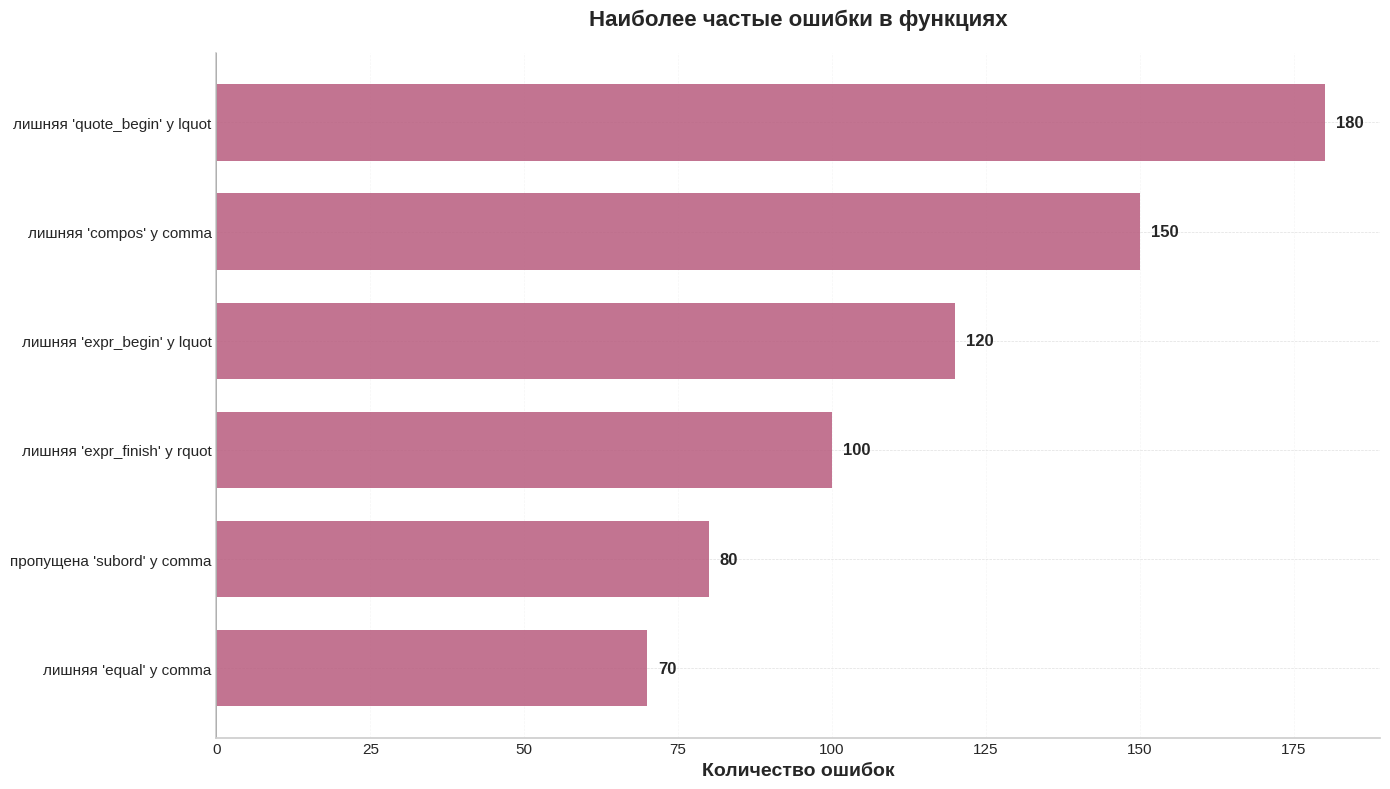


График сохранен в 'plots/most_common_function_errors.png'


In [5]:
errors = {
    "лишняя 'quote_begin' у lquot": 180,
    "лишняя 'compos' у comma": 150,
    "лишняя 'expr_begin' у lquot": 120,
    "лишняя 'expr_finish' у rquot": 100,
    "пропущена 'subord' у comma": 80,
    "лишняя 'equal' у comma": 70
}

sorted_errors = sorted(errors.items(), key=lambda x: x[1], reverse=False)
error_labels = [e[0] for e in sorted_errors]
error_counts = [e[1] for e in sorted_errors]

color = '#B85C7E'
fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(error_labels, error_counts, color=color, alpha=0.85, edgecolor='none', height=0.7)

max_count = max(error_counts)
for bar, count in zip(bars, error_counts):
    ax.text(bar.get_width() + max_count * 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{count}',
            ha='left', va='center',
            fontsize=12, fontweight='bold')

ax.set_xlabel('Количество ошибок', fontsize=14, fontweight='bold')
ax.set_title('Наиболее частые ошибки в функциях', fontsize=16, fontweight='bold', pad=20)

ax.grid(True, alpha=0.3, axis='x', linestyle='--')
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=11)

ax.axvline(x=0, color='black', linewidth=1.2)

plt.tight_layout()

plt.savefig('plots/most_common_function_errors.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\nГрафик сохранен в 'plots/most_common_function_errors.png'")